In [2]:
# --- Core data libraries ---
import numpy as np
import pandas as pd

# --- Visualisation libraries ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display settings ---
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')

# --- Reproducibility ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("All libraries imported successfully.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("Random seed set to 42 — all results are reproducible.")

All libraries imported successfully.
NumPy version: 2.4.3
Pandas version: 3.0.1
Random seed set to 42 — all results are reproducible.


# MTN NIGERIA PREPAID CHURN PREDICTION
     Phase 1 — Data Generation & Exploratory Data Analysis
     Author: Elijjjaaaahhhhh
     Dataset: NGA_MTN_Subscribers_500K (synthetic)
     Seed: 42 (all random operations use this seed for reproducibility)

In [3]:
# CELL 2 — DATASET PARAMETERS
# Define all constants that control dataset generation.

# --- Scale ---
N_SUBSCRIBERS = 500_000       # Total number of rows to generate
N_MONTHS      = 36            # Jan 2022 – Dec 2024

# --- Churn rate ---
BASE_MONTHLY_CHURN_RATE = 0.05   # 5% monthly churn (~25,000 churners)

# --- Nigerian states (36 states + FCT = 37 total) ---
NIGERIAN_STATES = [
    'Abia', 'Adamawa', 'Akwa Ibom', 'Anambra', 'Bauchi', 'Bayelsa',
    'Benue', 'Borno', 'Cross River', 'Delta', 'Ebonyi', 'Edo',
    'Ekiti', 'Enugu', 'Gombe', 'Imo', 'Jigawa', 'Kaduna', 'Kano',
    'Katsina', 'Kebbi', 'Kogi', 'Kwara', 'Lagos', 'Nasarawa', 'Niger',
    'Ogun', 'Ondo', 'Osun', 'Oyo', 'Plateau', 'Rivers', 'Sokoto',
    'Taraba', 'Yobe', 'Zamfara', 'FCT Abuja'
]

# --- States with higher churn (more competition, higher income) ---
HIGH_CHURN_STATES = ['Lagos', 'Kano', 'FCT Abuja', 'Rivers', 'Enugu']

# --- MTN Nigeria tariff plans ---
TARIFF_PLANS = ['MTNPulse', 'BetaGist', 'XtraValue', 'XtraSpecial', 'mPulse']

# --- Tariff plan weights (how common each plan is in the subscriber base) ---
# TalkMore is the most common prepaid plan
# SMEBundle is least common — it targets small businesses
TARIFF_WEIGHTS = [0.35, 0.15, 0.25, 0.15, 0.10]  # Must sum to 1.0

# --- State distribution weights ---
# Lagos, Kano, and Abuja have the largest subscriber bases
# We build this dynamically so every state gets a weight
STATE_WEIGHTS = []
for state in NIGERIAN_STATES:
    if state == 'Lagos':
        STATE_WEIGHTS.append(0.18)      # Lagos alone = 18% of subscribers
    elif state == 'Kano':
        STATE_WEIGHTS.append(0.07)      # Kano = 7%
    elif state == 'FCT Abuja':
        STATE_WEIGHTS.append(0.10)      # Abuja = 10%
    elif state == 'Rivers':
        STATE_WEIGHTS.append(0.06)      # Rivers = 6%
    elif state == 'Enugu':
        STATE_WEIGHTS.append(0.06)      # Enugu = 6%
    else:
        # Remaining 32 states share the remaining 53%
        STATE_WEIGHTS.append(0.53 / 32)

# Confirm weights sum to 1.0 (they must — this is a probability distribution)
assert round(sum(STATE_WEIGHTS), 6) == 1.0, "State weights must sum to 1.0"

# --- Observation months ---
import pandas as pd
OBSERVATION_MONTHS = pd.date_range(start='2022-01-01', periods=N_MONTHS, freq='MS')
# 'MS' = Month Start — generates the first day of each month

# --- Print confirmation ---
print(f"Dataset parameters defined.")
print(f"Total subscribers     : {N_SUBSCRIBERS:,}")
print(f"Observation period    : {OBSERVATION_MONTHS[0].strftime('%b %Y')} to {OBSERVATION_MONTHS[-1].strftime('%b %Y')}")
print(f"Number of months      : {N_MONTHS}")
print(f"Base monthly churn    : {BASE_MONTHLY_CHURN_RATE*100:.0f}%")
print(f"Number of states      : {len(NIGERIAN_STATES)}")
print(f"Tariff plans          : {TARIFF_PLANS}")
print(f"State weights sum     : {sum(STATE_WEIGHTS):.6f} ✓")


Dataset parameters defined.
Total subscribers     : 500,000
Observation period    : Jan 2022 to Dec 2024
Number of months      : 36
Base monthly churn    : 5%
Number of states      : 37
Tariff plans          : ['MTNPulse', 'BetaGist', 'XtraValue', 'XtraSpecial', 'mPulse']
State weights sum     : 1.000000 ✓


## DATASET GENERATION
    Generates 500,000 synthetic MTN Nigeria subscriber rows.
    Schema: 21 columns

In [4]:

# ============================================================

def generate_mtn_dataset(n_subscribers, random_seed=42):
    """
    Generates a synthetic MTN Nigeria prepaid subscriber dataset.

    INPUT:
        n_subscribers (int): Number of rows to generate
        random_seed   (int): Seed for reproducibility — default 42

    OUTPUT:
        pandas DataFrame with 21 columns and n_subscribers rows

    CHURN LOGIC:
        Trimodal probability distribution — clear low/medium/high
        risk clusters. 10 signal families documented below.
        Order: base → recency → frequency → multipliers →
               tenure → channel → segment-specific →
               interactions → seasonal → state → clip → draw
    """

    np.random.seed(random_seed)
    print(f"Generating {n_subscribers:,} subscriber records...")
    print("This may take 30–60 seconds. Please wait.")

    # --------------------------------------------------------
    # SECTION 1 — SUBSCRIBER IDs AND OBSERVATION MONTHS
    # --------------------------------------------------------

    subscriber_ids = [
        f"MTN-{np.random.randint(10000000, 99999999)}"
        for _ in range(n_subscribers)
    ]

    observation_months = np.random.choice(
        OBSERVATION_MONTHS, size=n_subscribers
    )

    # --------------------------------------------------------
    # SECTION 2 — SUBSCRIBER SEGMENT ASSIGNMENT
    # 45% Traditional | 55% Digital
    # --------------------------------------------------------

    subscriber_segment = np.random.choice(
        ['Traditional', 'Digital'],
        size=n_subscribers,
        p=[0.45, 0.55]
    )

    is_traditional = (subscriber_segment == 'Traditional')
    is_digital     = (subscriber_segment == 'Digital')

    # --------------------------------------------------------
    # SECTION 3 — STATE AND TARIFF PLAN
    # Assigned early — needed for interaction logic below
    # --------------------------------------------------------

    states = np.random.choice(
        NIGERIAN_STATES,
        size=n_subscribers,
        p=STATE_WEIGHTS
    )

    tariff_plans = np.random.choice(
        TARIFF_PLANS,
        size=n_subscribers,
        p=TARIFF_WEIGHTS
    )

    is_urban_state = np.isin(states, HIGH_CHURN_STATES)

    # --------------------------------------------------------
    # SECTION 4 — DAYS SINCE LAST RECHARGE
    # Traditional: scale=18 (slightly more dormant)
    # Digital:     scale=12 (more habitual recharging)
    # --------------------------------------------------------

    days_since_last_recharge = np.where(
        is_traditional,
        np.clip(
            np.random.exponential(scale=18, size=n_subscribers).astype(int),
            0, 90
        ),
        np.clip(
            np.random.exponential(scale=12, size=n_subscribers).astype(int),
            0, 90
        )
    )

    # --------------------------------------------------------
    # SECTION 5 — RECHARGE FREQUENCY
    # Traditional: lam=6 (frequent small top-ups)
    # Digital:     lam=4 (less frequent, larger bundles)
    # --------------------------------------------------------

    recharge_frequency_30d = np.where(
        is_traditional,
        np.clip(np.random.poisson(lam=6, size=n_subscribers), 0, 30),
        np.clip(np.random.poisson(lam=4, size=n_subscribers), 0, 30)
    )

    # --------------------------------------------------------
    # SECTION 6 — AVERAGE RECHARGE VALUE
    # Traditional: mass market ₦250 | high value ₦800
    # Digital:     mass market ₦800 | high value ₦2,500
    # --------------------------------------------------------

    trad_mass     = np.random.normal(loc=250, scale=100, size=n_subscribers)
    trad_high     = np.random.normal(loc=800, scale=200, size=n_subscribers)
    trad_flag     = np.random.binomial(1, 0.10, size=n_subscribers)
    trad_recharge = np.where(trad_flag == 1, trad_high, trad_mass)

    dig_mass      = np.random.normal(loc=800,  scale=300, size=n_subscribers)
    dig_high      = np.random.normal(loc=2500, scale=800, size=n_subscribers)
    dig_flag      = np.random.binomial(1, 0.20, size=n_subscribers)
    dig_recharge  = np.where(dig_flag == 1, dig_high, dig_mass)

    avg_recharge_value_naira = np.where(
        is_traditional, trad_recharge, dig_recharge
    )
    avg_recharge_value_naira = np.clip(
        avg_recharge_value_naira, 50, 5000
    ).round(2)

    # --------------------------------------------------------
    # SECTION 7 — USSD SESSIONS
    # Traditional: primary self-service channel (lam=30)
    # Digital:     uses app instead (lam=8)
    # --------------------------------------------------------

    ussd_sessions_30d = np.where(
        is_traditional,
        np.clip(np.random.poisson(lam=30, size=n_subscribers), 0, 200),
        np.clip(np.random.poisson(lam=8,  size=n_subscribers), 0, 200)
    )

    # --------------------------------------------------------
    # SECTION 8 — APP SESSIONS
    # Traditional: near-zero (lam=0.5)
    # Digital:     regular user (lam=12)
    # --------------------------------------------------------

    app_sessions_30d = np.where(
        is_traditional,
        np.clip(np.random.poisson(lam=0.5, size=n_subscribers), 0, 5),
        np.clip(np.random.poisson(lam=12,  size=n_subscribers), 0, 50)
    )

    # --------------------------------------------------------
    # SECTION 9 — DATA CONSUMPTION
    # Traditional: 0–2,000MB
    # Digital:     0–50,000MB
    # --------------------------------------------------------

    data_mb_consumed_30d = np.where(
        is_traditional,
        np.clip(
            np.random.exponential(scale=300,  size=n_subscribers).round(2),
            0, 2000
        ),
        np.clip(
            np.random.exponential(scale=6000, size=n_subscribers).round(2),
            0, 50000
        )
    )

    # --------------------------------------------------------
    # SECTION 10 — VOICE MINUTES
    # Traditional: high usage (loc=300)
    # Digital:     WhatsApp calls (loc=100)
    # --------------------------------------------------------

    voice_minutes_30d = np.where(
        is_traditional,
        np.clip(
            np.random.normal(loc=300, scale=120, size=n_subscribers).round(2),
            0, 1000
        ),
        np.clip(
            np.random.normal(loc=100, scale=80, size=n_subscribers).round(2),
            0, 1000
        )
    )

    # --------------------------------------------------------
    # SECTION 11 — SMS COUNT
    # Traditional: lam=25 | Digital: lam=5
    # --------------------------------------------------------

    sms_count_30d = np.where(
        is_traditional,
        np.clip(np.random.poisson(lam=25, size=n_subscribers), 0, 300),
        np.clip(np.random.poisson(lam=5,  size=n_subscribers), 0, 300)
    )

    # --------------------------------------------------------
    # SECTION 12 — BINARY FLAGS
    # --------------------------------------------------------

    network_complaint_flag = np.random.binomial(1, 0.08, size=n_subscribers)

    competitor_sim_detected = np.where(
        is_traditional,
        np.random.binomial(1, 0.10, size=n_subscribers),
        np.random.binomial(1, 0.22, size=n_subscribers)
    )

    number_portability_flag = np.where(
        is_traditional,
        np.random.binomial(1, 0.08, size=n_subscribers),
        np.random.binomial(1, 0.16, size=n_subscribers)
    )

    # --------------------------------------------------------
    # SECTION 13 — TENURE
    # Traditional: loc=48 (longer, established)
    # Digital:     loc=24 (younger, more recent)
    # --------------------------------------------------------

    tenure_months = np.where(
        is_traditional,
        np.clip(
            np.random.normal(loc=48, scale=24, size=n_subscribers).astype(int),
            1, 120
        ),
        np.clip(
            np.random.normal(loc=24, scale=18, size=n_subscribers).astype(int),
            1, 120
        )
    )

    # --------------------------------------------------------
    # SECTION 14 — RECHARGE CHANNEL
    # Boolean indexing — avoids np.where evaluating both
    # arrays before condition (dtype and logic safety)
    #
    # Traditional rural:  scratch card 20%
    # Traditional urban:  scratch card minimal 5%
    # Digital:            app and bank transfer dominant
    # --------------------------------------------------------

    recharge_channel = np.empty(n_subscribers, dtype=object)

    mask_trad_rural = is_traditional & ~is_urban_state
    n_trad_rural    = mask_trad_rural.sum()
    if n_trad_rural > 0:
        recharge_channel[mask_trad_rural] = np.random.choice(
            ['Scratch Card', 'Agent', 'USSD', 'Bank Transfer', 'MTN App'],
            size=n_trad_rural,
            p=[0.20, 0.30, 0.30, 0.15, 0.05]
        )

    mask_trad_urban = is_traditional & is_urban_state
    n_trad_urban    = mask_trad_urban.sum()
    if n_trad_urban > 0:
        recharge_channel[mask_trad_urban] = np.random.choice(
            ['Scratch Card', 'Agent', 'USSD', 'Bank Transfer', 'MTN App'],
            size=n_trad_urban,
            p=[0.05, 0.25, 0.35, 0.25, 0.10]
        )

    mask_digital = is_digital
    n_digital    = mask_digital.sum()
    if n_digital > 0:
        recharge_channel[mask_digital] = np.random.choice(
            ['Scratch Card', 'Agent', 'USSD', 'Bank Transfer', 'MTN App'],
            size=n_digital,
            p=[0.05, 0.10, 0.15, 0.45, 0.25]
        )

    # --------------------------------------------------------
    # SECTION 15 — BUNDLE TYPE
    # Boolean indexing — same reason as Section 14
    # Traditional: Voice Only 45% | Data Only 20% |
    #              Combo 30%      | Social 5%
    # Digital:     Voice Only 5%  | Data Only 45% |
    #              Combo 25%      | Social 25%
    # --------------------------------------------------------

    bundle_type = np.empty(n_subscribers, dtype=object)

    n_trad = is_traditional.sum()
    if n_trad > 0:
        bundle_type[is_traditional] = np.random.choice(
            ['Voice Only', 'Data Only',
             'Voice+Data Combo', 'Social Media Bundle'],
            size=n_trad,
            p=[0.45, 0.20, 0.30, 0.05]
        )

    n_dig = is_digital.sum()
    if n_dig > 0:
        bundle_type[is_digital] = np.random.choice(
            ['Voice Only', 'Data Only',
             'Voice+Data Combo', 'Social Media Bundle'],
            size=n_dig,
            p=[0.05, 0.45, 0.25, 0.25]
        )

    # --------------------------------------------------------
    # SECTION 16 — CUSTOMER SERVICE CONTACTS
    # Complaint subscribers: lam=3.5
    # Base subscribers:      lam=0.8
    # --------------------------------------------------------

    customer_service_contacts_30d = np.where(
        network_complaint_flag == 1,
        np.clip(np.random.poisson(lam=3.5, size=n_subscribers), 0, 10),
        np.clip(np.random.poisson(lam=0.8, size=n_subscribers), 0, 10)
    )

    # --------------------------------------------------------
    # SECTION 17 — CHURN PROBABILITY CALCULATION
    #
    # ORDER OF OPERATIONS:
    #   1.  Base rate
    #   2.  Recency (exponential tiers)
    #   3.  Complaint multiplier
    #   4.  Competitor SIM (tenure-decayed)
    #   5.  Number portability multiplier
    #   6.  Recharge frequency (conditional)
    #   7.  Tenure protective effects
    #   8.  Tariff plan signal
    #   9.  Recharge channel signal
    #  10.  Customer service escalation ladder
    #  11.  High value protective signal
    #  12.  Traditional-specific signals
    #  13.  Digital-specific signals
    #  14.  Triple interaction (highest risk profile)
    #  15.  Complaint + inactivity confirmation
    #  16.  Seasonal adjustments
    #  17.  State adjustments
    #  18.  Clip → Draw label
    # --------------------------------------------------------

    churn_prob = np.full(n_subscribers, BASE_MONTHLY_CHURN_RATE)

    # --------------------------------------------------
    # SIGNAL 1: Recency — EXPONENTIAL TIERS
    # Disengagement accelerates — not linear
    # 0–7 days:   minimal risk (just recharged)
    # 8–14 days:  normal gap
    # 15–21 days: concerning
    # 22–30 days: strong signal
    # 31–45 days: high risk
    # 46–90 days: near-certain churn
    # --------------------------------------------------
    d = days_since_last_recharge

    churn_prob += np.where(d <= 7,  0.02, 0.0)
    churn_prob += np.where((d > 7)  & (d <= 14), 0.08, 0.0)
    churn_prob += np.where((d > 14) & (d <= 21), 0.18, 0.0)
    churn_prob += np.where((d > 21) & (d <= 30), 0.32, 0.0)
    churn_prob += np.where((d > 30) & (d <= 45), 0.50, 0.0)
    churn_prob += np.where(d > 45,  0.70, 0.0)

    # --------------------------------------------------
    # SIGNAL 2: Network complaint — 2.3x multiplier
    # --------------------------------------------------
    churn_prob *= np.where(network_complaint_flag == 1, 2.3, 1.0)

    # --------------------------------------------------
    # SIGNAL 3: Competitor SIM — tenure-decayed multiplier
    # tenure < 12:  2.2x (no loyalty, already dual-SIM)
    # tenure 12–36: 1.8x (moderate risk)
    # tenure 37–60: 1.3x (supplementary SIM likely)
    # tenure > 60:  1.1x (5+ years — not leaving)
    # --------------------------------------------------
    has_competitor = competitor_sim_detected == 1

    competitor_multiplier = np.where(
        has_competitor & (tenure_months < 12),  2.2,
    np.where(
        has_competitor & (tenure_months < 37),  1.8,
    np.where(
        has_competitor & (tenure_months < 61),  1.3,
    np.where(
        has_competitor & (tenure_months >= 61), 1.1,
        1.0))))

    churn_prob *= competitor_multiplier

    # --------------------------------------------------
    # SIGNAL 4: Number portability — 1.4x multiplier
    # Already switched once = willing to switch again
    # --------------------------------------------------
    churn_prob *= np.where(number_portability_flag == 1, 1.4, 1.0)

    # --------------------------------------------------
    # SIGNAL 5: Recharge frequency — conditional
    #
    # Traditional + freq < 3 + low value:   +0.20
    # Traditional + freq < 3 + high value:  +0.10
    # Digital + freq < 3 + low value:       +0.15
    # Digital + freq < 3 + high value:      +0.04
    # --------------------------------------------------
    low_freq = recharge_frequency_30d < 3
    low_val  = avg_recharge_value_naira < 500

    churn_prob += np.where(
        is_traditional & low_freq & low_val,  0.20, 0.0)
    churn_prob += np.where(
        is_traditional & low_freq & ~low_val, 0.10, 0.0)
    churn_prob += np.where(
        is_digital & low_freq & low_val,      0.15, 0.0)
    churn_prob += np.where(
        is_digital & low_freq & ~low_val,     0.04, 0.0)

    # --------------------------------------------------
    # SIGNAL 6: Tenure protective effects
    # New subscribers: high risk (no loyalty built)
    # Long tenure:     protective (switching friction)
    #
    # tenure <= 3:    +0.20 (brand new — evaluation phase)
    # tenure 4–6:     +0.15 (still deciding)
    # tenure 7–12:    +0.08 (settling but not committed)
    # tenure > 36:    -0.08 (established — high friction)
    # tenure > 60:    -0.12 (very loyal — this is their number)
    # tenure > 84:    -0.15 (7+ years — extremely sticky)
    # --------------------------------------------------
    churn_prob += np.where(tenure_months <= 3,  0.20, 0.0)
    churn_prob += np.where(
        (tenure_months > 3) & (tenure_months <= 6),  0.15, 0.0)
    churn_prob += np.where(
        (tenure_months > 6) & (tenure_months <= 12), 0.08, 0.0)
    churn_prob -= np.where(tenure_months > 36, 0.08, 0.0)
    churn_prob -= np.where(tenure_months > 60, 0.12, 0.0)
    churn_prob -= np.where(tenure_months > 84, 0.15, 0.0)

    # Note: tenure > 84 months gets all three deductions:
    # -0.08 + -0.12 + -0.15 = -0.35 total protective effect
    # This correctly makes 7+ year subscribers very sticky

    # --------------------------------------------------
    # SIGNAL 7: Tariff plan signal
    # mPulse:      +0.07 (youth — highest price sensitivity)
    # BetaGist:    +0.05 (entertainment focus — social risk)
    # MTNPulse:    +0.02 (mass market — slight positive)
    # XtraValue:   +0.00 (neutral — value seekers stay)
    # XtraSpecial: -0.03 (premium — higher switching cost)
    # --------------------------------------------------
    churn_prob += np.where(tariff_plans == 'mPulse',      0.07, 0.0)
    churn_prob += np.where(tariff_plans == 'BetaGist',    0.05, 0.0)
    churn_prob += np.where(tariff_plans == 'MTNPulse',    0.02, 0.0)
    churn_prob += np.where(tariff_plans == 'XtraValue',   0.00, 0.0)
    churn_prob -= np.where(tariff_plans == 'XtraSpecial', 0.03, 0.0)

    # --------------------------------------------------
    # SIGNAL 8: Recharge channel signal
    # MTN App:       -0.08 (deeply integrated — lowest churn)
    # Bank Transfer: -0.03 (habitual digital — moderate loyalty)
    # USSD:          +0.00 (neutral — functional relationship)
    # Agent:         +0.04 (low digital integration)
    # Scratch Card:  tiered rural logic applied separately below
    # --------------------------------------------------
    churn_prob -= np.where(recharge_channel == 'MTN App',       0.08, 0.0)
    churn_prob -= np.where(recharge_channel == 'Bank Transfer', 0.03, 0.0)
    churn_prob += np.where(recharge_channel == 'Agent',         0.04, 0.0)

    # --------------------------------------------------
    # SIGNAL 9: Customer service escalation ladder
    #
    # contacts = 0:               -0.02 (never needed help)
    # contacts 1–2:               +0.00 (normal)
    # contacts 3–4, no complaint: +0.04 (multiple — not escalated)
    # contacts 3–4, complaint:    +0.12 (escalation pattern)
    # contacts >= 5, no complaint:+0.08 (high contact, unresolved)
    # contacts >= 5, complaint:   +0.20 (complete breakdown)
    # --------------------------------------------------
    c  = customer_service_contacts_30d
    cf = network_complaint_flag

    churn_prob -= np.where(c == 0, 0.02, 0.0)

    churn_prob += np.where(
        (c >= 3) & (c <= 4) & (cf == 0), 0.04, 0.0)
    churn_prob += np.where(
        (c >= 3) & (c <= 4) & (cf == 1), 0.12, 0.0)
    churn_prob += np.where(
        (c >= 5) & (cf == 0), 0.08, 0.0)
    churn_prob += np.where(
        (c >= 5) & (cf == 1), 0.20, 0.0)

    # --------------------------------------------------
    # SIGNAL 10: High value protective signal
    # avg recharge > ₦1,000: -0.05
    # avg recharge > ₦2,000: additional -0.05 (total -0.10)
    # --------------------------------------------------
    churn_prob -= np.where(avg_recharge_value_naira > 1000, 0.05, 0.0)
    churn_prob -= np.where(avg_recharge_value_naira > 2000, 0.05, 0.0)

    # --------------------------------------------------
    # TRADITIONAL-SPECIFIC SIGNALS
    # --------------------------------------------------

    # SIGNAL 11T: USSD decay — traditional disengagement
    # Not checking balance = mentally left
    churn_prob += np.where(
        is_traditional & (ussd_sessions_30d < 3), 0.15, 0.0
    )

    # SIGNAL 12T: Voice Only + complaint = network quality churn
    churn_prob += np.where(
        is_traditional &
        (bundle_type == 'Voice Only') &
        (network_complaint_flag == 1),
        0.08, 0.0
    )

    # SIGNAL 13T: Long tenure protective effect for traditional
    # Traditional subscriber with 3+ years = deeply habitual
    # Their contacts know this number — very high switching cost
    churn_prob -= np.where(
        is_traditional & (tenure_months > 36), 0.06, 0.0
    )

    # SIGNAL 14T: Scratch card frequency decay — rural only
    # Channel alone is not the risk — declining frequency is
    is_scratch_rural = (
        is_traditional &
        (recharge_channel == 'Scratch Card') &
        ~is_urban_state
    )

    # Tier 1: consistent buyer (freq >= 4) — near-zero risk
    churn_prob += np.where(
        is_scratch_rural & (recharge_frequency_30d >= 4),
        0.005, 0.0
    )
    # Tier 2: slowing (freq 2–3) — watch signal
    churn_prob += np.where(
        is_scratch_rural &
        (recharge_frequency_30d >= 2) &
        (recharge_frequency_30d < 4),
        0.02, 0.0
    )
    # Tier 3: collapsed (freq < 2) — strong disengagement
    churn_prob += np.where(
        is_scratch_rural & (recharge_frequency_30d < 2),
        0.08, 0.0
    )
    # Tier 3 confirmed: collapsed + long inactivity
    churn_prob += np.where(
        is_scratch_rural &
        (recharge_frequency_30d < 2) &
        (days_since_last_recharge > 21),
        0.05, 0.0
    )

    # --------------------------------------------------
    # DIGITAL-SPECIFIC SIGNALS
    # --------------------------------------------------

    # SIGNAL 15D: Social media bundle — tiered
    # Mutually exclusive tiers — most specific first
    is_social = is_digital & (bundle_type == 'Social Media Bundle')

    social_signal = np.where(
        is_social & (tenure_months < 12) & (recharge_frequency_30d < 3),
        0.14,
    np.where(
        is_social & (competitor_sim_detected == 1),
        0.12,
    np.where(
        is_social & (tenure_months >= 24) & (recharge_frequency_30d >= 4),
        0.01,
    np.where(
        is_social,
        0.08,
        0.0))))

    churn_prob += social_signal

    # SIGNAL 16D: Low app sessions — digital disengagement
    churn_prob += np.where(
        is_digital & (app_sessions_30d < 2), 0.06, 0.0
    )

    # SIGNAL 17D: Low data stacked — three tiers
    # Most specific first — mutually exclusive
    low_data         = is_digital & (data_mb_consumed_30d < 500)
    low_app          = app_sessions_30d < 2
    low_freq_digital = recharge_frequency_30d < 3

    data_signal = np.where(
        low_data & low_app & low_freq_digital, 0.18,
    np.where(
        low_data & low_app,                    0.10,
    np.where(
        low_data,                              0.05,
        0.0)))

    churn_prob += data_signal

    # SIGNAL 18D: High data consumption protective signal
    # Heavy data users have built their digital life on MTN
    # Switching means disrupting streaming, downloads, backups
    churn_prob -= np.where(
        is_digital & (data_mb_consumed_30d > 15000), 0.10, 0.0)
    churn_prob -= np.where(
        is_digital & (data_mb_consumed_30d > 5000),  0.05, 0.0)

    # --------------------------------------------------
    # SIGNAL 19: TRIPLE INTERACTION
    # Highest risk profile in the entire dataset:
    # Digital + competitor SIM + Social Media Bundle +
    # urban state + tenure < 12 months
    # = subscriber who is new, price-sensitive, already
    #   evaluating competitors, in a high-competition market
    # This profile should have probability 0.75–0.90
    # --------------------------------------------------
    triple_risk = (
        is_digital &
        (competitor_sim_detected == 1) &
        (bundle_type == 'Social Media Bundle') &
        is_urban_state &
        (tenure_months < 12)
    )
    churn_prob += np.where(triple_risk, 0.25, 0.0)

    # --------------------------------------------------
    # SIGNAL 20: Complaint + inactivity confirmation
    # Complained AND stopped recharging = mentally left
    # Different from just complaining and still recharging
    # --------------------------------------------------
    churn_prob += np.where(
        (network_complaint_flag == 1) &
        (days_since_last_recharge > 14),
        0.15, 0.0
    )

    # --------------------------------------------------------
    # SECTION 18 — SEASONAL ADJUSTMENTS
    # January:  post-holiday cash squeeze  → +0.10
    # July–Aug: school fees pressure       → +0.07
    # December: end-of-year spending shift → +0.04
    # --------------------------------------------------------

    months = pd.DatetimeIndex(observation_months).month
    churn_prob += np.where(months == 1,  0.10, 0.0)
    churn_prob += np.where(
        (months == 7) | (months == 8),   0.07, 0.0)
    churn_prob += np.where(months == 12, 0.04, 0.0)

    # --------------------------------------------------------
    # SECTION 19 — STATE-LEVEL ADJUSTMENTS
    # Urban high-churn states:          +0.12
    # Urban digital subscribers:        additional +0.10
    # Rural non-urban states:           -0.04 protective
    # (fewer alternatives, coverage parity across operators)
    # --------------------------------------------------------

    churn_prob += np.where(is_urban_state,  0.12, 0.0)
    churn_prob += np.where(
        is_digital & is_urban_state,        0.10, 0.0)
    churn_prob -= np.where(~is_urban_state, 0.04, 0.0)

    # --------------------------------------------------------
    # SECTION 20 — CLIP AND DRAW FINAL CHURN LABEL
    # --------------------------------------------------------

    churn_prob = np.clip(churn_prob, 0.01, 0.95)
    churn_label = np.random.binomial(1, churn_prob)

    # --------------------------------------------------------
    # SECTION 21 — ASSEMBLE THE DATAFRAME
    # --------------------------------------------------------

    df = pd.DataFrame({
        'subscriber_id'                : subscriber_ids,
        'observation_month'            : observation_months,
        'subscriber_segment'           : subscriber_segment,
        'days_since_last_recharge'     : days_since_last_recharge,
        'recharge_frequency_30d'       : recharge_frequency_30d,
        'avg_recharge_value_naira'     : avg_recharge_value_naira,
        'ussd_sessions_30d'            : ussd_sessions_30d,
        'app_sessions_30d'             : app_sessions_30d,
        'data_mb_consumed_30d'         : data_mb_consumed_30d,
        'voice_minutes_30d'            : voice_minutes_30d,
        'sms_count_30d'                : sms_count_30d,
        'network_complaint_flag'       : network_complaint_flag,
        'competitor_sim_detected'      : competitor_sim_detected,
        'number_portability_flag'      : number_portability_flag,
        'tenure_months'                : tenure_months,
        'recharge_channel'             : recharge_channel,
        'bundle_type'                  : bundle_type,
        'customer_service_contacts_30d': customer_service_contacts_30d,
        'tariff_plan'                  : tariff_plans,
        'state'                        : states,
        'churn_label'                  : churn_label
    })

    print(f"Dataset generated successfully.")
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

    return df


# --- Run the function ---
df = generate_mtn_dataset(N_SUBSCRIBERS, random_seed=RANDOM_SEED)

# --- Quick preview ---
print(f"\nFirst 3 rows:")
print(df.head(3).to_string())


Generating 500,000 subscriber records...
This may take 30–60 seconds. Please wait.
Dataset generated successfully.
Shape: 500,000 rows × 21 columns

First 3 rows:
  subscriber_id observation_month subscriber_segment  days_since_last_recharge  recharge_frequency_30d  avg_recharge_value_naira  ussd_sessions_30d  app_sessions_30d  data_mb_consumed_30d  voice_minutes_30d  sms_count_30d  network_complaint_flag  competitor_sim_detected  number_portability_flag  tenure_months recharge_channel          bundle_type  customer_service_contacts_30d  tariff_plan   state  churn_label
0  MTN-75682867        2024-06-01            Digital                        25                       4                   1376.28                  8                11               8121.67             103.72              6                       0                        0                        0             36    Bank Transfer  Social Media Bundle                              2  XtraSpecial  Jigawa            0
1  MTN-66

## DATA QUALITY CHECKS
 Validates the generated dataset before any analysis begins.

In [5]:
# Every check uses assert — if anything fails, the notebook
# stops immediately with a clear error message.

print("=" * 60)
print("DATA QUALITY REPORT — NGA_MTN_Subscribers_500K")
print("=" * 60)

# --------------------------------------------------------
# CHECK 1 — SHAPE
# Must be exactly 500,000 rows and 21 columns
# --------------------------------------------------------

print("\n[CHECK 1] Shape")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")

assert df.shape[0] == 500_000, \
    f"FAIL: Expected 500,000 rows, got {df.shape[0]:,}"
assert df.shape[1] == 21, \
    f"FAIL: Expected 21 columns, got {df.shape[1]}"

print("  STATUS  : PASSED ✓")

# --------------------------------------------------------
# CHECK 2 — DATA TYPES
# Pandas 3.0 stores string columns as dtype='str'
# Older Pandas stored them as dtype=object
# We accept both to stay version-compatible
# --------------------------------------------------------

print("\n[CHECK 2] Data Types")
print(df.dtypes.to_string())

# Helper: acceptable string dtypes across Pandas versions
STRING_DTYPES = [object, 'str', 'string']

# String columns
assert df['subscriber_id'].dtype in STRING_DTYPES, \
    f"FAIL: subscriber_id should be string, got {df['subscriber_id'].dtype}"

assert df['subscriber_segment'].dtype in STRING_DTYPES, \
    f"FAIL: subscriber_segment should be string, got {df['subscriber_segment'].dtype}"

assert df['recharge_channel'].dtype in STRING_DTYPES, \
    f"FAIL: recharge_channel should be string, got {df['recharge_channel'].dtype}"

assert df['bundle_type'].dtype in STRING_DTYPES, \
    f"FAIL: bundle_type should be string, got {df['bundle_type'].dtype}"

assert df['tariff_plan'].dtype in STRING_DTYPES, \
    f"FAIL: tariff_plan should be string, got {df['tariff_plan'].dtype}"

assert df['state'].dtype in STRING_DTYPES, \
    f"FAIL: state should be string, got {df['state'].dtype}"

# Datetime column
assert str(df['observation_month'].dtype).startswith('datetime'), \
    f"FAIL: observation_month should be datetime, got {df['observation_month'].dtype}"

# Integer columns
INT_DTYPES = ['int32', 'int64']

assert df['days_since_last_recharge'].dtype in INT_DTYPES, \
    f"FAIL: days_since_last_recharge should be int, got {df['days_since_last_recharge'].dtype}"

assert df['recharge_frequency_30d'].dtype in INT_DTYPES, \
    f"FAIL: recharge_frequency_30d should be int, got {df['recharge_frequency_30d'].dtype}"

assert df['ussd_sessions_30d'].dtype in INT_DTYPES, \
    f"FAIL: ussd_sessions_30d should be int, got {df['ussd_sessions_30d'].dtype}"

assert df['app_sessions_30d'].dtype in INT_DTYPES, \
    f"FAIL: app_sessions_30d should be int, got {df['app_sessions_30d'].dtype}"

assert df['sms_count_30d'].dtype in INT_DTYPES, \
    f"FAIL: sms_count_30d should be int, got {df['sms_count_30d'].dtype}"

assert df['network_complaint_flag'].dtype in INT_DTYPES, \
    f"FAIL: network_complaint_flag should be int, got {df['network_complaint_flag'].dtype}"

assert df['competitor_sim_detected'].dtype in INT_DTYPES, \
    f"FAIL: competitor_sim_detected should be int, got {df['competitor_sim_detected'].dtype}"

assert df['number_portability_flag'].dtype in INT_DTYPES, \
    f"FAIL: number_portability_flag should be int, got {df['number_portability_flag'].dtype}"

assert df['tenure_months'].dtype in INT_DTYPES, \
    f"FAIL: tenure_months should be int, got {df['tenure_months'].dtype}"

assert df['customer_service_contacts_30d'].dtype in INT_DTYPES, \
    f"FAIL: customer_service_contacts_30d should be int, got {df['customer_service_contacts_30d'].dtype}"

assert df['churn_label'].dtype in INT_DTYPES, \
    f"FAIL: churn_label should be int, got {df['churn_label'].dtype}"

# Float columns
FLOAT_DTYPES = ['float32', 'float64']

assert df['avg_recharge_value_naira'].dtype in FLOAT_DTYPES, \
    f"FAIL: avg_recharge_value_naira should be float, got {df['avg_recharge_value_naira'].dtype}"

assert df['data_mb_consumed_30d'].dtype in FLOAT_DTYPES, \
    f"FAIL: data_mb_consumed_30d should be float, got {df['data_mb_consumed_30d'].dtype}"

assert df['voice_minutes_30d'].dtype in FLOAT_DTYPES, \
    f"FAIL: voice_minutes_30d should be float, got {df['voice_minutes_30d'].dtype}"

print("\n  STATUS  : PASSED ✓")

# --------------------------------------------------------
# CHECK 3 — NULL VALUES
# We generated this data — there should be zero nulls.
# Any null means something went wrong in Cell 3.
# --------------------------------------------------------

print("\n[CHECK 3] Null Values")
null_counts  = df.isnull().sum()
total_nulls  = null_counts.sum()

print(f"  Total null values across all columns: {total_nulls}")

if total_nulls > 0:
    print("\n  Columns with nulls:")
    print(null_counts[null_counts > 0].to_string())

assert total_nulls == 0, \
    f"FAIL: Found {total_nulls} null values — check Cell 3 generation logic"

print("  STATUS  : PASSED ✓")

# --------------------------------------------------------
# CHECK 4 — VALUE RANGES
# Confirm every numeric column is within its defined range.
# We print min and max for every column so we can spot
# anything suspicious even if it passes the assert.
# --------------------------------------------------------

print("\n[CHECK 4] Value Ranges")
print(f"  {'Column':<35} {'Min':>10} {'Max':>12} {'Status'}")
print(f"  {'-'*35} {'-'*10} {'-'*12} {'-'*8}")

# (column_name, min_allowed, max_allowed)
range_checks = [
    ('days_since_last_recharge',       0,     90),
    ('recharge_frequency_30d',         0,     30),
    ('avg_recharge_value_naira',       50,  5000),
    ('ussd_sessions_30d',              0,    200),
    ('app_sessions_30d',               0,     50),
    ('data_mb_consumed_30d',           0,  50000),
    ('voice_minutes_30d',              0,   1000),
    ('sms_count_30d',                  0,    300),
    ('network_complaint_flag',         0,      1),
    ('competitor_sim_detected',        0,      1),
    ('number_portability_flag',        0,      1),
    ('tenure_months',                  1,    120),
    ('customer_service_contacts_30d',  0,     10),
    ('churn_label',                    0,      1),
]

all_ranges_passed = True
for col, min_val, max_val in range_checks:
    actual_min = df[col].min()
    actual_max = df[col].max()
    passed     = (actual_min >= min_val) and (actual_max <= max_val)
    status     = "PASSED ✓" if passed else "FAILED ✗"
    print(f"  {col:<35} {actual_min:>10.2f} {actual_max:>12.2f} {status}")
    if not passed:
        all_ranges_passed = False
        print(f"    Expected range: [{min_val}, {max_val}]")

assert all_ranges_passed, \
    "FAIL: One or more columns have values outside their expected range"

print(f"\n  STATUS  : PASSED ✓")

# --------------------------------------------------------
# CHECK 5 — CATEGORICAL VALUE VALIDATION
# Confirm only valid categories exist in each column
# --------------------------------------------------------

print("\n[CHECK 5] Categorical Values")

# subscriber_segment
valid_segments  = {'Traditional', 'Digital'}
actual_segments = set(df['subscriber_segment'].unique())
assert actual_segments == valid_segments, \
    f"FAIL: subscriber_segment unexpected values: {actual_segments - valid_segments}"
print(f"  subscriber_segment    : {sorted(actual_segments)} ✓")

# tariff_plan
valid_plans  = set(TARIFF_PLANS)
actual_plans = set(df['tariff_plan'].unique())
assert actual_plans == valid_plans, \
    f"FAIL: tariff_plan unexpected values: {actual_plans - valid_plans}"
print(f"  tariff_plan           : {sorted(actual_plans)} ✓")

# recharge_channel
valid_channels  = {'Scratch Card', 'Agent', 'USSD', 'Bank Transfer', 'MTN App'}
actual_channels = set(df['recharge_channel'].unique())
assert actual_channels == valid_channels, \
    f"FAIL: recharge_channel unexpected values: {actual_channels - valid_channels}"
print(f"  recharge_channel      : {sorted(actual_channels)} ✓")

# bundle_type
valid_bundles  = {'Voice Only', 'Data Only', 'Voice+Data Combo', 'Social Media Bundle'}
actual_bundles = set(df['bundle_type'].unique())
assert actual_bundles == valid_bundles, \
    f"FAIL: bundle_type unexpected values: {actual_bundles - valid_bundles}"
print(f"  bundle_type           : {sorted(actual_bundles)} ✓")

# state
valid_states  = set(NIGERIAN_STATES)
actual_states = set(df['state'].unique())
assert actual_states == valid_states, \
    f"FAIL: state unexpected values: {actual_states - valid_states}"
print(f"  state                 : all 37 states present ✓")

print(f"\n  STATUS  : PASSED ✓")

# --------------------------------------------------------
# CHECK 6 — CHURN RATE AND SEGMENT DISTRIBUTION
# Churn rate will be higher than the 5% base rate because
# the signal boosting in Cell 3 pushes many subscribers
# into higher probability buckets before the binary draw.
# Expected range: 10%–30%
# --------------------------------------------------------

print("\n[CHECK 6] Churn Rate and Segment Distribution")

overall_churn_rate = df['churn_label'].mean() * 100
churned_count      = df['churn_label'].sum()
retained_count     = len(df) - churned_count

print(f"\n  Churn label distribution:")
print(f"  Churned  (1) : {churned_count:>8,}  ({overall_churn_rate:.2f}%)")
print(f"  Retained (0) : {retained_count:>8,}  ({100 - overall_churn_rate:.2f}%)")

# Segment distribution
segment_counts = df['subscriber_segment'].value_counts()
trad_pct       = segment_counts.get('Traditional', 0) / len(df) * 100
dig_pct        = segment_counts.get('Digital',     0) / len(df) * 100

print(f"\n  Segment distribution:")
print(f"  Traditional  : {segment_counts.get('Traditional', 0):>8,}  ({trad_pct:.1f}%)")
print(f"  Digital      : {segment_counts.get('Digital',     0):>8,}  ({dig_pct:.1f}%)")

# Churn rate by segment
trad_churn = df[df['subscriber_segment'] == 'Traditional']['churn_label'].mean() * 100
dig_churn  = df[df['subscriber_segment'] == 'Digital'    ]['churn_label'].mean() * 100

print(f"\n  Churn rate by segment:")
print(f"  Traditional churn rate : {trad_churn:.2f}%")
print(f"  Digital churn rate     : {dig_churn:.2f}%")

# Churn rate by high-churn states vs rest
high_churn_mask    = df['state'].isin(HIGH_CHURN_STATES)
urban_churn_rate   = df[high_churn_mask ]['churn_label'].mean() * 100
rural_churn_rate   = df[~high_churn_mask]['churn_label'].mean() * 100

print(f"\n  Churn rate by geography:")
print(f"  Urban high-churn states : {urban_churn_rate:.2f}%")
print(f"  All other states        : {rural_churn_rate:.2f}%")

# Assert churn rate is in expected range
assert 10 <= overall_churn_rate <= 30, \
    f"FAIL: Overall churn rate {overall_churn_rate:.2f}% outside " \
    f"expected range [10%, 30%]. Check signal logic in Cell 3."

# Assert segment split is within 3pp of target
assert abs(trad_pct - 45) <= 3, \
    f"FAIL: Traditional segment {trad_pct:.1f}%, expected ~45%"
assert abs(dig_pct - 55) <= 3, \
    f"FAIL: Digital segment {dig_pct:.1f}%, expected ~55%"

# Assert digital churn is higher than traditional
# (Urban digital subscribers have more competitor exposure)
assert dig_churn > trad_churn, \
    f"FAIL: Digital churn ({dig_churn:.2f}%) should exceed " \
    f"Traditional churn ({trad_churn:.2f}%) — check segment signals"

print(f"\n  STATUS  : PASSED ✓")

# --------------------------------------------------------
# CHECK 7 — SUBSCRIBER ID FORMAT
# All IDs must match MTN-XXXXXXXX (MTN- + 8 digits)
# --------------------------------------------------------

print("\n[CHECK 7] Subscriber ID Format")

id_format_check = df['subscriber_id'].str.match(r'^MTN-\d{8}$')
malformed_count = (~id_format_check).sum()

print(f"  Total IDs             : {len(df):,}")
print(f"  Correctly formatted   : {id_format_check.sum():,}")
print(f"  Malformed IDs         : {malformed_count}")

assert malformed_count == 0, \
    f"FAIL: {malformed_count} subscriber IDs do not match MTN-XXXXXXXX format"

print(f"  STATUS  : PASSED ✓")

# --------------------------------------------------------
# FINAL SUMMARY
# --------------------------------------------------------

print("\n" + "=" * 60)
print("DATA QUALITY REPORT — SUMMARY")
print("=" * 60)
print(f"  Check 1 — Shape              : PASSED ✓")
print(f"  Check 2 — Data Types         : PASSED ✓")
print(f"  Check 3 — Null Values        : PASSED ✓")
print(f"  Check 4 — Value Ranges       : PASSED ✓")
print(f"  Check 5 — Categorical Values : PASSED ✓")
print(f"  Check 6 — Churn Distribution : PASSED ✓")
print(f"  Check 7 — ID Format          : PASSED ✓")
print("=" * 60)
print(f"  Dataset is clean and ready for EDA.")
print("=" * 60)

DATA QUALITY REPORT — NGA_MTN_Subscribers_500K

[CHECK 1] Shape
  Rows    : 500,000
  Columns : 21
  STATUS  : PASSED ✓

[CHECK 2] Data Types
subscriber_id                               str
observation_month                datetime64[us]
subscriber_segment                          str
days_since_last_recharge                  int64
recharge_frequency_30d                    int32
avg_recharge_value_naira                float64
ussd_sessions_30d                         int32
app_sessions_30d                          int32
data_mb_consumed_30d                    float64
voice_minutes_30d                       float64
sms_count_30d                             int32
network_complaint_flag                    int32
competitor_sim_detected                   int32
number_portability_flag                   int32
tenure_months                             int64
recharge_channel                            str
bundle_type                                 str
customer_service_contacts_30d             

## EXPLORATORY DATA ANALYSIS (EDA)
8 visualisations answering core business questions.
All charts use consistent styling for portfolio presentation.

Business questions answered:
   1. Where is churn concentrated geographically?
   2. Do new subscribers churn more than long-tenure ones?
   3. Which tariff plans have a retention problem?
   4. Do Traditional and Digital segments churn differently?
   5. Which bundle types are highest risk?
   6. How different is recharge recency between churners/retained?
   7. Which features are correlated with each other?
   8. Is there a seasonal churn pattern over 36 months?

In [6]:
# --- Chart styling constants ---
BACKGROUND_COLOR = '#1B2A4A'   # Navy — matches Power BI dashboard theme
TEXT_COLOR       = '#FFFFFF'   # White text on dark background
ACCENT_COLOR     = '#C9973A'   # Gold accent — MTN brand adjacent
ALERT_COLOR      = '#B33A3A'   # Red — used for high churn bars
NEUTRAL_COLOR    = '#4A90D9'   # Blue — used for low churn / retained

# Apply dark background to all charts in this session
plt.rcParams['figure.facecolor']  = BACKGROUND_COLOR
plt.rcParams['axes.facecolor']    = BACKGROUND_COLOR
plt.rcParams['axes.labelcolor']   = TEXT_COLOR
plt.rcParams['xtick.color']       = TEXT_COLOR
plt.rcParams['ytick.color']       = TEXT_COLOR
plt.rcParams['text.color']        = TEXT_COLOR
plt.rcParams['axes.titlecolor']   = TEXT_COLOR
plt.rcParams['axes.edgecolor']    = '#3A4A6A'
plt.rcParams['grid.color']        = '#2A3A5A'
plt.rcParams['font.family']       = 'Segoe UI'

print("Building EDA visualisations...")
print("=" * 60)


Building EDA visualisations...


### CHART 1 — CHURN RATE BY STATE (TOP 10)
 Business question: Where geographically is MTN losing the most subscribers?

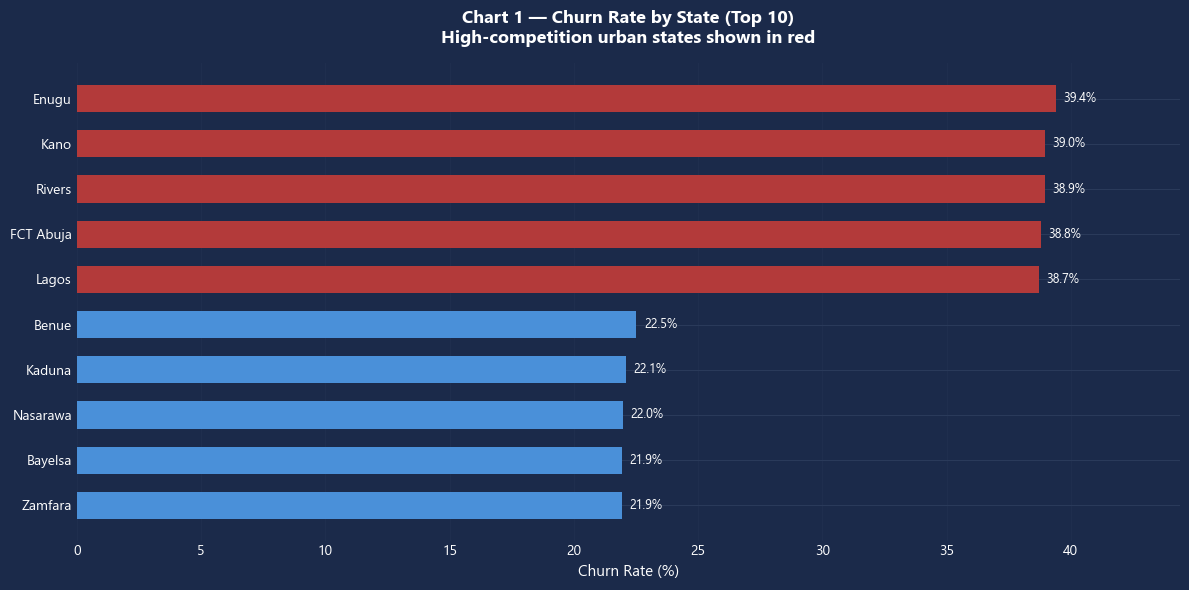

Chart 1 saved ✓


In [7]:
# Calculate churn rate per state
state_churn = (
    df.groupby('state')['churn_label']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'subscriber_count'})
    .reset_index()
)
state_churn['churn_rate_pct'] = state_churn['churn_rate'] * 100

# Sort and take top 10 by churn rate
top10_states = state_churn.sort_values('churn_rate_pct', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))

# Colour bars: high-churn states in alert red, others in neutral blue
bar_colors = [
    ALERT_COLOR if state in HIGH_CHURN_STATES else NEUTRAL_COLOR
    for state in top10_states['state']
]

bars = ax.barh(
    top10_states['state'],
    top10_states['churn_rate_pct'],
    color=bar_colors,
    edgecolor='none',
    height=0.6
)

# Annotate each bar with the percentage
for bar, pct in zip(bars, top10_states['churn_rate_pct']):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}%',
        va='center', ha='left',
        color=TEXT_COLOR, fontsize=9
    )

ax.set_xlabel('Churn Rate (%)', fontsize=11)
ax.set_title(
    'Chart 1 — Churn Rate by State (Top 10)\n'
    'High-competition urban states shown in red',
    fontsize=13, pad=15, fontweight='bold'
)
ax.invert_yaxis()
ax.set_xlim(0, top10_states['churn_rate_pct'].max() + 5)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/chart1_churn_by_state.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND_COLOR)
plt.show()
print("Chart 1 saved ✓")


### CHART 2 — CHURN RATE BY TENURE BAND
 Business question: Are new subscribers or long-tenure subscribers more likely to churn?

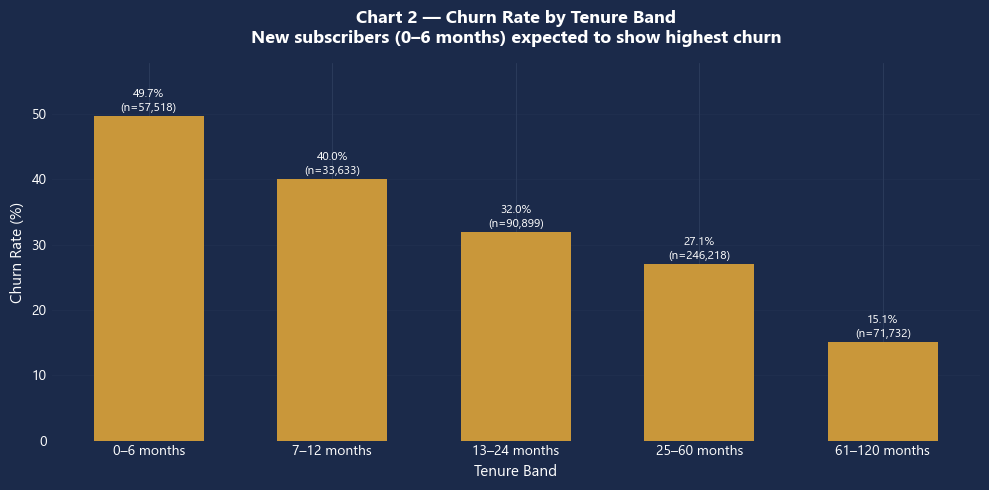

Chart 2 saved ✓


In [8]:
# Create tenure bands
tenure_bins   = [0, 6, 12, 24, 60, 120]
tenure_labels = ['0–6 months', '7–12 months', '13–24 months',
                 '25–60 months', '61–120 months']

df['tenure_band'] = pd.cut(
    df['tenure_months'],
    bins=tenure_bins,
    labels=tenure_labels,
    right=True
)

tenure_churn = (
    df.groupby('tenure_band', observed=True)['churn_label']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'count'})
    .reset_index()
)
tenure_churn['churn_rate_pct'] = tenure_churn['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    tenure_churn['tenure_band'].astype(str),
    tenure_churn['churn_rate_pct'],
    color=ACCENT_COLOR,
    edgecolor='none',
    width=0.6
)

# Annotate bars
for bar, pct, cnt in zip(bars,
                          tenure_churn['churn_rate_pct'],
                          tenure_churn['count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%\n(n={cnt:,})',
        ha='center', va='bottom',
        color=TEXT_COLOR, fontsize=8.5
    )

ax.set_xlabel('Tenure Band', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title(
    'Chart 2 — Churn Rate by Tenure Band\n'
    'New subscribers (0–6 months) expected to show highest churn',
    fontsize=13, pad=15, fontweight='bold'
)
ax.set_ylim(0, tenure_churn['churn_rate_pct'].max() + 8)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/chart2_churn_by_tenure.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND_COLOR)
plt.show()
print("Chart 2 saved ✓")


### CHART 3 — CHURN RATE BY TARIFF PLAN
 Business question: Which MTN plans have a retention problem?

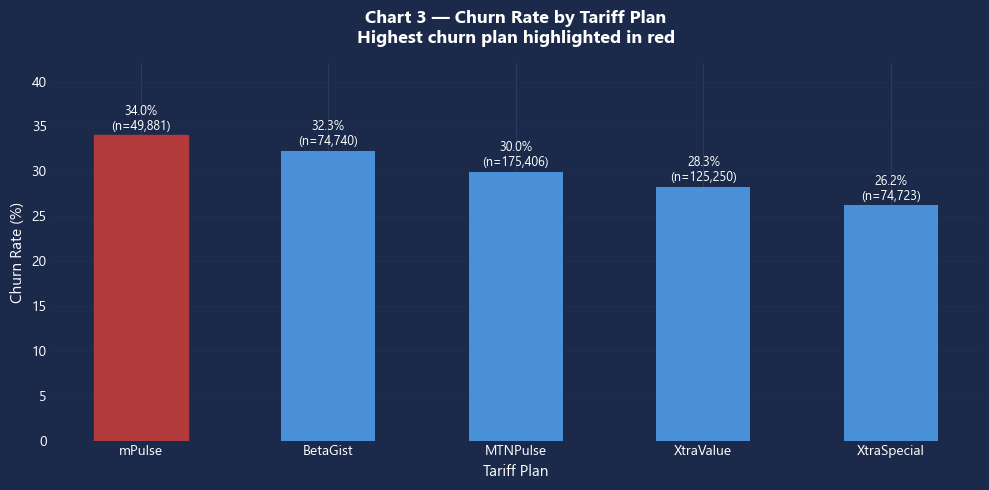

Chart 3 saved ✓


In [9]:
plan_churn = (
    df.groupby('tariff_plan')['churn_label']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'count'})
    .reset_index()
    .sort_values('churn_rate', ascending=False)
)
plan_churn['churn_rate_pct'] = plan_churn['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    plan_churn['tariff_plan'],
    plan_churn['churn_rate_pct'],
    color=NEUTRAL_COLOR,
    edgecolor='none',
    width=0.5
)

# Highlight the highest churn plan in alert red
bars[0].set_color(ALERT_COLOR)

for bar, pct, cnt in zip(bars,
                          plan_churn['churn_rate_pct'],
                          plan_churn['count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%\n(n={cnt:,})',
        ha='center', va='bottom',
        color=TEXT_COLOR, fontsize=9
    )

ax.set_xlabel('Tariff Plan', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title(
    'Chart 3 — Churn Rate by Tariff Plan\n'
    'Highest churn plan highlighted in red',
    fontsize=13, pad=15, fontweight='bold'
)
ax.set_ylim(0, plan_churn['churn_rate_pct'].max() + 8)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/chart3_churn_by_tariff.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND_COLOR)
plt.show()
print("Chart 3 saved ✓")


### CHART 4 — CHURN RATE BY SUBSCRIBER SEGMENT
 Business question: Do Traditional and Digital subscribers
 churn at different rates?

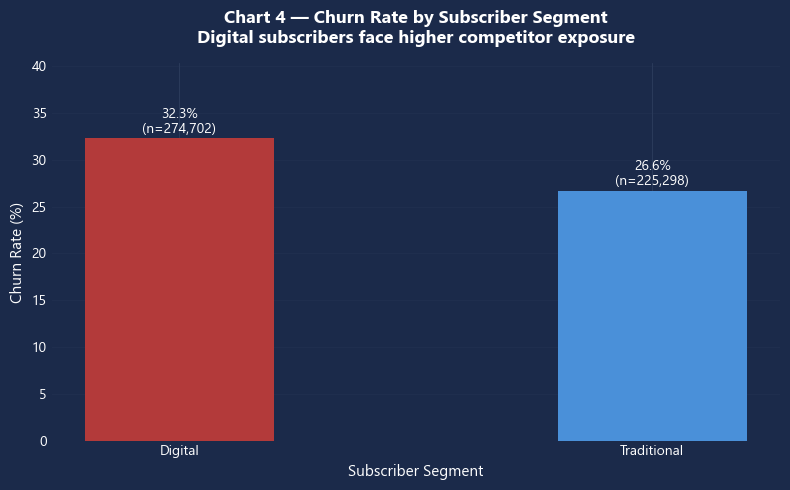

Chart 4 saved ✓


In [10]:
segment_churn = (
    df.groupby('subscriber_segment')['churn_label']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'count'})
    .reset_index()
    .sort_values('churn_rate', ascending=False)
)
segment_churn['churn_rate_pct'] = segment_churn['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(8, 5))

seg_colors = [ALERT_COLOR if seg == 'Digital' else NEUTRAL_COLOR
              for seg in segment_churn['subscriber_segment']]

bars = ax.bar(
    segment_churn['subscriber_segment'],
    segment_churn['churn_rate_pct'],
    color=seg_colors,
    edgecolor='none',
    width=0.4
)

for bar, pct, cnt in zip(bars,
                          segment_churn['churn_rate_pct'],
                          segment_churn['count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%\n(n={cnt:,})',
        ha='center', va='bottom',
        color=TEXT_COLOR, fontsize=10
    )

ax.set_xlabel('Subscriber Segment', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title(
    'Chart 4 — Churn Rate by Subscriber Segment\n'
    'Digital subscribers face higher competitor exposure',
    fontsize=13, pad=15, fontweight='bold'
)
ax.set_ylim(0, segment_churn['churn_rate_pct'].max() + 8)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/chart4_churn_by_segment.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND_COLOR)
plt.show()
print("Chart 4 saved ✓")


### CHART 5 — CHURN RATE BY BUNDLE TYPE
 Business question: Which bundle types are highest risk?

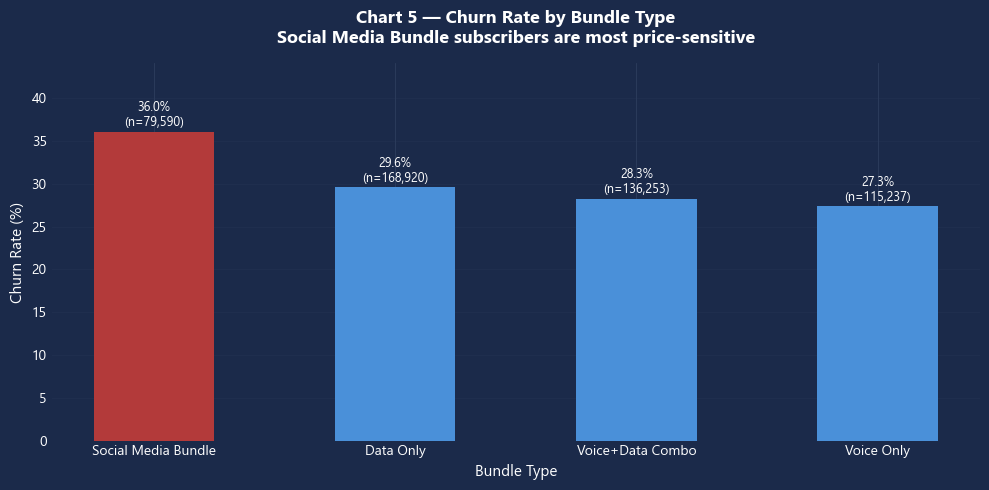

Chart 5 saved ✓


In [11]:
bundle_churn = (
    df.groupby('bundle_type')['churn_label']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'count'})
    .reset_index()
    .sort_values('churn_rate', ascending=False)
)
bundle_churn['churn_rate_pct'] = bundle_churn['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(10, 5))

bundle_colors = [
    ALERT_COLOR if b == 'Social Media Bundle' else NEUTRAL_COLOR
    for b in bundle_churn['bundle_type']
]

bars = ax.bar(
    bundle_churn['bundle_type'],
    bundle_churn['churn_rate_pct'],
    color=bundle_colors,
    edgecolor='none',
    width=0.5
)

for bar, pct, cnt in zip(bars,
                          bundle_churn['churn_rate_pct'],
                          bundle_churn['count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%\n(n={cnt:,})',
        ha='center', va='bottom',
        color=TEXT_COLOR, fontsize=9
    )

ax.set_xlabel('Bundle Type', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title(
    'Chart 5 — Churn Rate by Bundle Type\n'
    'Social Media Bundle subscribers are most price-sensitive',
    fontsize=13, pad=15, fontweight='bold'
)
ax.set_ylim(0, bundle_churn['churn_rate_pct'].max() + 8)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/chart5_churn_by_bundle.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND_COLOR)
plt.show()
print("Chart 5 saved ✓")


### CHART 6 — DAYS SINCE LAST RECHARGE: CHURNED VS RETAINED
 Business question: How different is recharge recency
 between subscribers who churned and those who stayed?

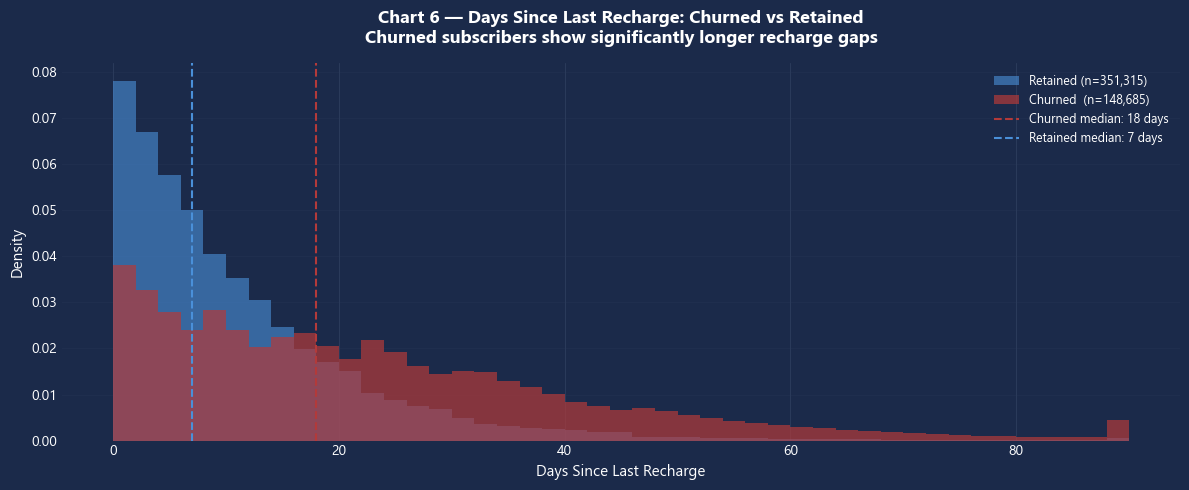

Chart 6 saved ✓


In [12]:
churned  = df[df['churn_label'] == 1]['days_since_last_recharge']
retained = df[df['churn_label'] == 0]['days_since_last_recharge']

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(retained, bins=45, alpha=0.6, color=NEUTRAL_COLOR,
        label=f'Retained (n={len(retained):,})',
        density=True, edgecolor='none')
ax.hist(churned,  bins=45, alpha=0.7, color=ALERT_COLOR,
        label=f'Churned  (n={len(churned):,})',
        density=True, edgecolor='none')

# Vertical lines for median of each group
ax.axvline(churned.median(),  color=ALERT_COLOR,  linestyle='--',
           linewidth=1.5, label=f'Churned median: {churned.median():.0f} days')
ax.axvline(retained.median(), color=NEUTRAL_COLOR, linestyle='--',
           linewidth=1.5, label=f'Retained median: {retained.median():.0f} days')

ax.set_xlabel('Days Since Last Recharge', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(
    'Chart 6 — Days Since Last Recharge: Churned vs Retained\n'
    'Churned subscribers show significantly longer recharge gaps',
    fontsize=13, pad=15, fontweight='bold'
)
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/chart6_recharge_recency_dist.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND_COLOR)
plt.show()
print("Chart 6 saved ✓")


### CHART 7 — CORRELATION HEATMAP
 Business question: Which features move together?
 Are there redundant signals in our dataset?

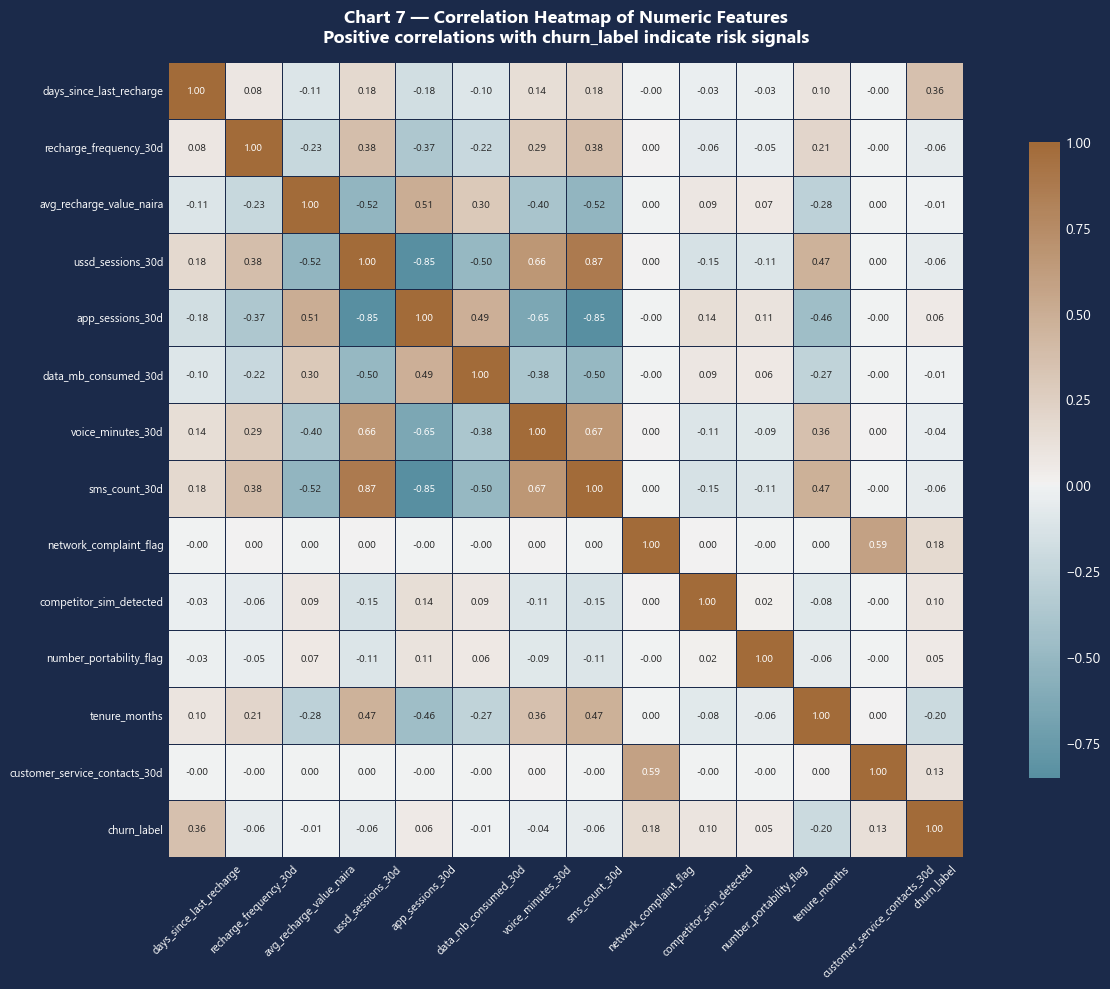

Chart 7 saved ✓


In [13]:
numeric_cols = [
    'days_since_last_recharge',
    'recharge_frequency_30d',
    'avg_recharge_value_naira',
    'ussd_sessions_30d',
    'app_sessions_30d',
    'data_mb_consumed_30d',
    'voice_minutes_30d',
    'sms_count_30d',
    'network_complaint_flag',
    'competitor_sim_detected',
    'number_portability_flag',
    'tenure_months',
    'customer_service_contacts_30d',
    'churn_label'
]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))

# Custom diverging colormap — navy to gold
import matplotlib.colors as mcolors
cmap = sns.diverging_palette(220, 40, as_cmap=True)

sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap=cmap,
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7.5},
    linewidths=0.5,
    linecolor='#1B2A4A',
    square=True,
    cbar_kws={'shrink': 0.8}
)

ax.set_title(
    'Chart 7 — Correlation Heatmap of Numeric Features\n'
    'Positive correlations with churn_label indicate risk signals',
    fontsize=13, pad=15, fontweight='bold'
)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig('../outputs/chart7_correlation_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND_COLOR)
plt.show()
print("Chart 7 saved ✓")


### CHART 8 — MONTHLY CHURN TREND (JAN 2022 – DEC 2024)
 Business question: Is churn getting better or worse
 over time? Are seasonal spikes visible?

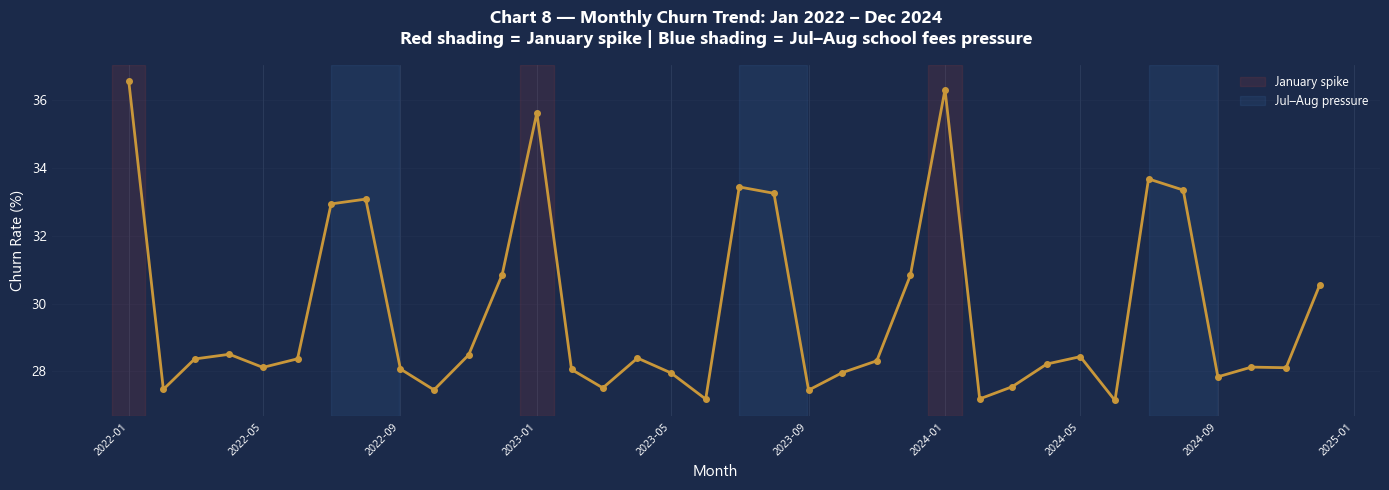

Chart 8 saved ✓

All charts generated and saved successfully!


In [14]:
# Calculate monthly churn rate
monthly_churn = (
    df.groupby('observation_month')['churn_label']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'count'})
    .reset_index()
    .sort_values('observation_month')
)
monthly_churn['churn_rate_pct'] = monthly_churn['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    monthly_churn['observation_month'],
    monthly_churn['churn_rate_pct'],
    color=ACCENT_COLOR,
    linewidth=2,
    marker='o',
    markersize=4,
    markerfacecolor=ACCENT_COLOR
)

# Shade January spikes (post-holiday)
for year in [2022, 2023, 2024]:
    jan_date = pd.Timestamp(f'{year}-01-01')
    ax.axvspan(
        jan_date - pd.Timedelta(days=15),
        jan_date + pd.Timedelta(days=15),
        alpha=0.15, color=ALERT_COLOR,
        label='January spike' if year == 2022 else ''
    )

# Shade July–August (school fees)
for year in [2022, 2023, 2024]:
    ax.axvspan(
        pd.Timestamp(f'{year}-07-01'),
        pd.Timestamp(f'{year}-08-31'),
        alpha=0.10, color=NEUTRAL_COLOR,
        label='Jul–Aug pressure' if year == 2022 else ''
    )

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title(
    'Chart 8 — Monthly Churn Trend: Jan 2022 – Dec 2024\n'
    'Red shading = January spike | Blue shading = Jul–Aug school fees pressure',
    fontsize=13, pad=15, fontweight='bold'
)
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/chart8_monthly_churn_trend.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND_COLOR)
plt.show()
print("Chart 8 saved ✓")
print("\nAll charts generated and saved successfully!")

### EDA SUMMARY — KEY FINDINGS

In [15]:
print("\n" + "=" * 60)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 60)

print(f"\n  Overall churn rate          : {df['churn_label'].mean()*100:.2f}%")
print(f"  Highest churn state         : {top10_states.iloc[0]['state']} "
      f"({top10_states.iloc[0]['churn_rate_pct']:.1f}%)")
print(f"  Lowest tenure band churn    : {tenure_churn.sort_values('churn_rate_pct').iloc[0]['tenure_band']} "
      f"({tenure_churn.sort_values('churn_rate_pct').iloc[0]['churn_rate_pct']:.1f}%)")
print(f"  Highest tenure band churn   : {tenure_churn.sort_values('churn_rate_pct', ascending=False).iloc[0]['tenure_band']} "
      f"({tenure_churn.sort_values('churn_rate_pct', ascending=False).iloc[0]['churn_rate_pct']:.1f}%)")
print(f"  Highest churn tariff plan   : {plan_churn.iloc[0]['tariff_plan']} "
      f"({plan_churn.iloc[0]['churn_rate_pct']:.1f}%)")
print(f"  Highest churn bundle type   : {bundle_churn.iloc[0]['bundle_type']} "
      f"({bundle_churn.iloc[0]['churn_rate_pct']:.1f}%)")
print(f"  Digital vs Traditional churn: {dig_churn:.1f}% vs {trad_churn:.1f}%")
print(f"  Churned median recency      : {churned.median():.0f} days")
print(f"  Retained median recency     : {retained.median():.0f} days")
print(f"  Recency gap                 : {churned.median() - retained.median():.0f} days")

print("\n" + "=" * 60)
print("  All 8 charts saved to outputs/ folder")
print("=" * 60)


EDA SUMMARY — KEY FINDINGS

  Overall churn rate          : 29.74%
  Highest churn state         : Enugu (39.4%)
  Lowest tenure band churn    : 61–120 months (15.1%)
  Highest tenure band churn   : 0–6 months (49.7%)
  Highest churn tariff plan   : mPulse (34.0%)
  Highest churn bundle type   : Social Media Bundle (36.0%)
  Digital vs Traditional churn: 32.3% vs 26.6%
  Churned median recency      : 18 days
  Retained median recency     : 7 days
  Recency gap                 : 11 days

  All 8 charts saved to outputs/ folder
